# Which tREs are responding differently to TFs for WSP B2B-cells, and ADP and UPM treated smAECs?

    A. SRF is only significantly called in WSP, but very strongly. What are these same tREs doing in smAECs perturbed with ADP and UPM?
        - Indeed they are interspersed across rankings.
    B. AHR is significantly called in WSP and UPM. Are the tREs used different or the same?
        - They are mostly different.


In [ ]:
library(data.table)
library(ggplot2)
library(stringr)
library(cowplot)

## A. SRF showed significant results for WSP but not UPM2.5. What are the tREs responding to SRF in WSP B2B cells doing in smAECs perturbed with UPM2.5?

1. Get the SRF responding tREs using the leading edge
2. See where they are ranked for ADP and UPM.

### A1. Get SRF responding tREs in WSP B2B cells with the leading edge & motifs

In [2]:
# read in the results (including leading edge) for WSP B2B
read_in_results <- function(file_name) {
    res = as.data.frame(fread(file_name))
    colnames(res) <- c("TF", "Escore", "CorrEscore", "Events", "GC", "FPKM", "Padj", "CorrPadj", 
                      "MB_LE", "MB_LE_stdev", "SE_LE", "SE_LE_stdev", "Frac_abov_null", "NA")

    res$CorrPadj <- as.numeric(res$CorrPadj)
    res$Padj <- as.numeric(res$Padj)
    res$Gen_TF <- str_split_fixed(res$TF, "[.]", 2)[,1]

    # Order from Correced Padj
    res = res[order(res$CorrPadj),]
    res = res[,c("TF", "Gen_TF", "Escore", "CorrEscore", "Events", "GC", "Padj", "CorrPadj", 
                      "MB_LE", "MB_LE_stdev", "SE_LE", "SE_LE_stdev", "Frac_abov_null")]

    return(res)
    }

get_LE_calls <- function(resdir, ranked_file, TF="SRF.H12CORE.0.PSM.A", nontss=TRUE) {
    # read in the results
    res_calls = read_in_results(paste0(resdir, "/results.txt"))
    # read in the distance df
    dist_df = fread(paste0(resdir, "temp_files/withAUC", TF, "__dis_andmore.csv"), sep=",")
    # add tRE names from ranked file
    rank_df = fread(ranked_file)
    dist_df$V1 <- seq(1, nrow(dist_df))
    dist_df$name = paste0(rank_df[["#chrom"]], ":", rank_df$start, "-", rank_df$stop)
    # only consider those within the leading edge (consider Enrichment score)
    if (res_calls[res_calls$TF == TF,]$Padj < 0.05 | res_calls[res_calls$TF == TF,]$CorrPadj < 0.05) {
    LE = res_calls[res_calls$TF == TF,]$SE_LE[1]
    ES = res_calls[res_calls$TF == TF,]$Escore[1]
    if (ES > 0) {
        dist_df = dist_df[1:LE,]
        } else {
        LE = nrow(dist_df) - LE
        dist_df = dist_df[LE:nrow(dist_df),]
        }
    # only consider those with motif within 500bp 
    dist_df = dist_df[dist_df$distances_abs != ".",]
    dist_df$distances_abs <- as.numeric(dist_df$distances_abs)
    dist_df = dist_df[dist_df$distances_abs < 501,]
    print(dist_df$V1)
    gen_TF = str_split_fixed(TF, "[.]", 2)[,1]
    cat("\n", gen_TF, "LE:", LE, "\tEScore:", ES, "\tCorrEScore:", res_calls[res_calls$TF == TF,]$CorrEscore[1], "\tNum in LE mu500:", length(dist_df$name))
    return (dist_df$name) } else {
        cat("\nNo significant calls for this", res_calls[res_calls$TF == TF,]$Padj, res_calls[res_calls$TF == TF,]$CorrPadj)
        }
    }

In [28]:
outdir = "/scratch/Users/hoto7260/Resp_Env/Comb_UPM_WSP_ADP/"
wspindir = "/scratch/Users/hoto7260/Resp_Env/Comb_UPM_WSP_ADP/WSP/TFEA/input/"
upmindir = "/scratch/Users/hoto7260/Resp_Env/Comb_UPM_WSP_ADP/UPM/TFEA/input/"

In [7]:
ranked_file = paste0(wspindir, "NonTSS_WSP30_vs_Veh_par_rat_Wd_GeneHK.bed")
resdir = paste0(outdir, "WSP/TFEA/out/NonTSS_WSP30vsVeh_par_rat_Wd_GeneHK_noback/")
pro_30_srf = get_LE_calls(resdir, ranked_file, "SRF.H12CORE.0.PSM.A")

ranked_file = paste0(wspindir, "GeneTSS_WSP30_vs_Veh_par_rat_Wd_GeneHK.bed")
resdir = paste0(outdir, "WSP/TFEA/out/Gene_WSP30vsVeh_par_rat_Wd_GeneHK_noback/")
pro_30_srf_gene = get_LE_calls(resdir, ranked_file, "SRF.H12CORE.0.PSM.A")

Warning message in fread(file_name):
“Detected 13 column names but the data has 14 columns (i.e. invalid file). Added 1 extra default column name for the first column which is guessed to be row names or an index. Use setnames() afterwards if this guess is not correct, or fix the file write command that created the file to create a valid file.”


 [1]   12   13   24   33   43   52   57   64   66   82   94  136  143  161  170
[16]  189  190  227  228  233  241  254  260  261  268  285  286  295  326  357
[31]  367  375  415  432  433  434  457  463  470  477  498  508  513  515  525
[46]  528  536  538  542  548  589  595  600  613  614  616  637  659  661  678
[61]  682  686  698  706  756  761  787  802  803  806  808  809  817  835  846
[76]  884  886  904  910  926  947  970  983  990  998 1006 1011 1050 1052 1055
[91] 1063 1069 1070 1087 1125

 SRF LE: 1134 	EScore: 0.356816 	CorrEScore: 0.3237673 	Num in LE mu500: 95

Warning message in fread(file_name):
“Detected 13 column names but the data has 14 columns (i.e. invalid file). Added 1 extra default column name for the first column which is guessed to be row names or an index. Use setnames() afterwards if this guess is not correct, or fix the file write command that created the file to create a valid file.”


 [1]   1   3   5  12  19  21  23  30  34  46  48  66  73 111 141 156 160 202 248
[20] 257 270 294 302 321 369 381 408 446 477 526 541 551

 SRF LE: 557 	EScore: 0.2582044 	CorrEScore: 0.2044448 	Num in LE mu500: 32

In [4]:

# gene_res_W30 <- read_in_results(paste0(outdir, "WSP/TFEA/out/Gene_WSP30vsVeh_par_rat_Wd_HK/results.txt"))
# nontss_res_W30 <- read_in_results(paste0(outdir, "WSP/TFEA/out/NonTSS_WSP30vsVeh_par_rat_Wd_HK/results.txt"))
# gene_res_W30[1:2,]
# resdir = paste0(outdir, "WSP/TFEA/out/NonTSS_WSP30vsVeh_par_rat_Wd_GeneHK_noback/")
# TF="SRF.H12CORE.0.PSM.A"

# dist_df = fread(ranked_file)
# dist_df[1:2,]



Warning message in fread(file_name):
“Detected 13 column names but the data has 14 columns (i.e. invalid file). Added 1 extra default column name for the first column which is guessed to be row names or an index. Use setnames() afterwards if this guess is not correct, or fix the file write command that created the file to create a valid file.”
Warning message in fread(file_name):
“Detected 13 column names but the data has 14 columns (i.e. invalid file). Added 1 extra default column name for the first column which is guessed to be row names or an index. Use setnames() afterwards if this guess is not correct, or fix the file write command that created the file to create a valid file.”


,TF,Gen_TF,Escore,CorrEscore,Events,GC,Padj,CorrPadj,MB_LE,MB_LE_stdev,SE_LE,SE_LE_stdev,Frac_abov_null
,<chr>,<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,ZN362.H12CORE.0.P.C,ZN362,-0.02125835,-0.1509506,6572,0.1116749,1e+00,1e-45,4971,NaN,1519,NaN,0.49
2,ZN143.H12CORE.0.P.B,ZN143,-0.16377539,-0.1633434,1524,0.5222282,1e-10,1e-10,7315,24.14,1381,786.22,0.43


ERROR: Error in eval(expr, envir, enclos): object 'ranked_file' not found


In [13]:
ranked_file = paste0(wspindir, "NonTSS_WSP120_vs_Veh_par_rat_Wd_GeneHK.bed")
resdir = paste0(outdir, "WSP/TFEA/out/NonTSS_WSP120vsVeh_par_rat_Wd_GeneHK_noback/")
pro_120_srf = get_LE_calls(resdir, ranked_file, "SRF.H12CORE.0.PSM.A")

ranked_file = paste0(wspindir, "GeneTSS_WSP120_vs_Veh_par_rat_Wd_GeneHK.bed")
resdir = paste0(outdir, "WSP/TFEA/out/Gene_WSP120vsVeh_par_rat_Wd_GeneHK_noback/")
pro_120_srf_gene = get_LE_calls(resdir, ranked_file, "SRF.H12CORE.0.PSM.A")


No significant calls for this 1 1
No significant calls for this 1 1

### A2. See where LE calls rank on the ADP and UPM ones

In [14]:
read_ranked_file <- function(file_name) {
    rank_df = fread(file_name)
    rank_df$name = paste0(rank_df[["#chrom"]], ":", rank_df$start, "-", rank_df$stop)
    # add rankings
    rank_df$V1 <- seq(1, nrow(rank_df))
    return(rank_df)
    }


In [35]:
graph_rankings <- function(TF_use, gene_tss_list, nontss_list, gene=TRUE, file_save="", color="blue") {
    # Read in the ranked files
    ranked_wsp120 = read_ranked_file(paste0(wspindir, "NonTSS_WSP120_vs_Veh_par_rat_Wd_GeneHK.bed"))
    ranked_wsp30 = read_ranked_file(paste0(wspindir, "NonTSS_WSP30_vs_Veh_par_rat_Wd_GeneHK.bed"))
    ranked_wsp120_gene = read_ranked_file(paste0(wspindir, "GeneTSS_WSP120_vs_Veh_par_rat_Wd_GeneHK.bed"))
    ranked_wsp30_gene = read_ranked_file(paste0(wspindir, "GeneTSS_WSP30_vs_Veh_par_rat_Wd_GeneHK.bed"))
    
    ranked_upm120 = read_ranked_file(paste0(upmindir, "NonTSS_UPM120_vs_Veh_par_rat_Wd_GeneHK.bed"))
    ranked_upm30 = read_ranked_file(paste0(upmindir, "NonTSS_UPM30_vs_Veh_par_rat_Wd_GeneHK.bed"))
    ranked_upm120_gene = read_ranked_file(paste0(upmindir, "GeneTSS_UPM120_vs_Veh_par_rat_Wd_GeneHK.bed"))
    ranked_upm30_gene = read_ranked_file(paste0(upmindir, "GeneTSS_UPM30_vs_Veh_par_rat_Wd_GeneHK.bed"))
    
    adpindir = "/scratch/Users/hoto7260/Resp_Env/Comb_UPM_WSP_ADP/ADP/TFEA/input/"
    ranked_adp = read_ranked_file(paste0(adpindir, "NonTSS_ADP_vs_Veh_par_rat_Wd_HK.bed"))
    ranked_adp_gene = read_ranked_file(paste0(adpindir, "GeneTSS_ADP_vs_Veh_par_rat_Wd_HK.bed"))
    # Read in the distance files
    wspresdir = paste0(outdir, "WSP/TFEA/out")
    dist_wsp120 = fread(paste0(wspresdir, "/NonTSS_WSP120vsVeh_par_rat_Wd_GeneHK_noback/temp_files/withAUC", TF_use, "__dis_andmore.csv"), sep=",")
    dist_wsp30 = fread(paste0(wspresdir, "/NonTSS_WSP30vsVeh_par_rat_Wd_GeneHK_noback/temp_files/withAUC", TF_use, "__dis_andmore.csv"), sep=",")
    dist_wsp120_gene = fread(paste0(wspresdir, "/Gene_WSP120vsVeh_par_rat_Wd_GeneHK_noback/temp_files/withAUC", TF_use, "__dis_andmore.csv"), sep=",")
    dist_wsp30_gene = fread(paste0(wspresdir, "/Gene_WSP30vsVeh_par_rat_Wd_GeneHK_noback/temp_files/withAUC", TF_use, "__dis_andmore.csv"), sep=",")
    upmresdir = paste0(outdir, "UPM/TFEA/out")
    dist_upm120 = fread(paste0(upmresdir, "/NonTSS_UPM120vsVeh_par_rat_Wd_GeneHK_noback/temp_files/withAUC", TF_use, "__dis_andmore.csv"), sep=",")
    dist_upm30 = fread(paste0(upmresdir, "/NonTSS_UPM30vsVeh_par_rat_Wd_GeneHK_noback/temp_files/withAUC", TF_use, "__dis_andmore.csv"), sep=",")
    dist_upm120_gene = fread(paste0(upmresdir, "/Gene_UPM120vsVeh_par_rat_Wd_GeneHK_noback/temp_files/withAUC", TF_use, "__dis_andmore.csv"), sep=",")
    dist_upm30_gene = fread(paste0(upmresdir, "/Gene_UPM30vsVeh_par_rat_Wd_GeneHK_noback/temp_files/withAUC", TF_use, "__dis_andmore.csv"), sep=",")
    adpresdir = paste0(outdir, "ADP/TFEA/out")
    dist_adp = fread(paste0(adpresdir, "/NonTSS_ADP_par_rat_Wd_HK_noback/temp_files/withAUC", TF_use, "__dis_andmore.csv"), sep=",")
    dist_adp_gene = fread(paste0(adpresdir, "/Gene_ADP_par_rat_Wd_HK_noback/temp_files/withAUC", TF_use, "__dis_andmore.csv"), sep=",")
    
    # Get info for TF
    gen_TF_use = str_split(TF_use, "[.]")[[1]][1]

    # Get the colors according to if in the 
    # gene_tss_list
    # nontss_list
    # Get the color for the rankings
    ranked_wsp120$Color <- "0"
    ranked_wsp30$Color <- "0"
    ranked_wsp120_gene$Color <- "0"
    ranked_wsp30_gene$Color <- "0"
    ranked_upm120$Color <- "0"
    ranked_upm30$Color <- "0"
    ranked_upm120_gene$Color <- "0"
    ranked_upm30_gene$Color <- "0"
    ranked_adp$Color <- "0"
    ranked_adp_gene$Color <- "0"

    ranked_wsp120[ranked_wsp120$name %in% nontss_list,]$Color <- "LE"
    ranked_wsp30[ranked_wsp30$name %in% nontss_list,]$Color <- "LE"
    ranked_upm120[ranked_upm120$name %in% nontss_list,]$Color <- "LE"
    ranked_upm30[ranked_upm30$name %in% nontss_list,]$Color <- "LE"
    ranked_adp[ranked_adp$name %in% nontss_list,]$Color <- "LE"
    ranked_wsp120_gene[ranked_wsp120_gene$name %in% gene_tss_list,]$Color <- "LE"
    ranked_wsp30_gene[ranked_wsp30_gene$name %in% gene_tss_list,]$Color <- "LE"
    ranked_upm120_gene[ranked_upm120_gene$name %in% gene_tss_list,]$Color <- "LE"
    ranked_upm30_gene[ranked_upm30_gene$name %in% gene_tss_list,]$Color <- "LE"
    ranked_adp_gene[ranked_adp_gene$name %in% gene_tss_list,]$Color <- "LE"
    print(table(ranked_upm30$Color))
    # Get the heatmap data
    get_heatmap_data <- function(ranked_df, bin_size = 200) {
      df <- as.data.table(ranked_df[ranked_df$Color %in% c("LE"), ])
      if (nrow(df) == 0 || all(is.na(df$V1))) {
    warning("No LE entries or all V1 values are NA. Returning empty data.table.")
    return(data.table(V1_bin = numeric(), N = numeric()))
  }
      df[, V1_bin := floor(V1 / bin_size) * bin_size]

    
    
      # Create full bin sequence across the range of V1
      bin_range <- seq(floor(min(df$V1) / bin_size) * bin_size,
                       ceiling(max(df$V1) / bin_size) * bin_size,
                       by = bin_size)
    
      # Count observations in each bin
      heatmap_data <- df[, .N, by = V1_bin]
    
      # Merge with full bin range to ensure all bins are represented
      all_bins <- data.table(V1_bin = bin_range)
      heatmap_data <- merge(all_bins, heatmap_data, by = "V1_bin", all.x = TRUE)
      heatmap_data[is.na(N), N := 0]
    
      return(heatmap_data)
    }
    print(table(ranked_upm30$Color))
    cat("\nRanked UPM30", nrow(ranked_upm30))
    hmp_wsp30_data = get_heatmap_data(ranked_wsp30)
    hmp_wsp120_data = get_heatmap_data(ranked_wsp120)
    hmp_upm30_data = get_heatmap_data(ranked_upm30)
    hmp_upm120_data = get_heatmap_data(ranked_upm120)
    hmp_adp_data = get_heatmap_data(ranked_adp)
    cat("UPM30", nrow(hmp_upm30_data), "\tUPM120", nrow(hmp_upm120_data), "\tWSP120", nrow(hmp_wsp120_data))
    print(table(hmp_wsp30_data$N))
    if (gene == TRUE) {
        hmp_wsp30_gene_data = get_heatmap_data(ranked_wsp30_gene, 100)
        hmp_wsp120_gene_data = get_heatmap_data(ranked_wsp120_gene, 100)
        hmp_upm30_gene_data = get_heatmap_data(ranked_upm30_gene, 100)
        hmp_upm120_gene_data = get_heatmap_data(ranked_upm120_gene, 100)
        hmp_adp_gene_data = get_heatmap_data(ranked_adp_gene, 100)
        }
    
    # Plot with geom_tile
    no_margin_theme <- theme(
      plot.margin = margin(0, 0, 0, 0),  # Remove outer margins
      axis.text = element_blank(),       # Remove axis text
      axis.ticks = element_blank(),      # Remove axis ticks
      panel.spacing = unit(0, "lines"),  # Remove spacing between facets
      panel.grid = element_blank(),      # Remove grid lines
        axis.title = element_blank(), 
     legend.position = "none",           # Remove legend if not needed
        axis.line = element_line(color = "black")
    )
    x_range <- range(ranked_wsp30$V1) 
    p1 = ggplot(hmp_wsp30_data, aes(x = V1_bin, y = 1, fill = N)) +
      geom_tile() + scale_fill_gradient(low = "white", high = color) +
      labs(fill = "Count") + theme_minimal() + ylim(0.5, 1.9) + no_margin_theme + geom_vline(xintercept=0, color="black") + 
    geom_vline(xintercept=nrow(ranked_wsp30), color="black") +
    scale_x_continuous(limits = range(floor(x_range[1]/200)*200, ceiling(x_range[2]/200)*200)) +
    annotate("text", label=paste0("WSP30 N=", length(nontss_list)), x=3400, y = 1.75, size=5)
    x_range <- range(ranked_wsp120$V1) 
    p2 = ggplot(hmp_wsp120_data, aes(x = V1_bin, y = 1, fill = N)) +
      geom_tile() + scale_fill_gradient(low = "white", high = color) + geom_vline(xintercept=0, color="black") + 
    geom_vline(xintercept=nrow(ranked_wsp120), color="black") +
      labs(fill = "Count") + theme_minimal() +  no_margin_theme + ylim(0.5, 1.9) +
    scale_x_continuous(limits = range(floor(x_range[1]/200)*200, ceiling(x_range[2]/200)*200)) +
    annotate("text", label=paste0("WSP120 N=", length(nontss_list)), x=3600, y = 1.75, size=5)
    p3 = ggplot(hmp_upm30_data, aes(x = V1_bin, y = 1, fill = N)) +
      geom_tile() + scale_fill_gradient(low = "white", high = color) +
      labs(fill = "Count") + theme_minimal() + ylim(0.5, 1.9) + no_margin_theme + geom_vline(xintercept=0, color="black") + 
    geom_vline(xintercept=nrow(ranked_wsp120), color="black") +
    scale_x_continuous(limits = range(floor(x_range[1]/200)*200, ceiling(x_range[2]/200)*200)) +
    annotate("text", label=paste0("UPM30 N=", length(nontss_list)), x=3400, y = 1.75, size=5)
    x_range <- range(ranked_upm120$V1) 
    p4 = ggplot(hmp_upm120_data, aes(x = V1_bin, y = 1, fill = N)) +
      geom_tile() + scale_fill_gradient(low = "white", high = color) + geom_vline(xintercept=0, color="black") + 
    geom_vline(xintercept=nrow(ranked_upm120), color="black") +
      labs(fill = "Count") + theme_minimal() +  no_margin_theme + ylim(0.5, 1.9) +
    scale_x_continuous(limits = range(floor(x_range[1]/200)*200, ceiling(x_range[2]/200)*200)) +
    annotate("text", label=paste0("UPM120 N=", length(nontss_list)), x=3600, y = 1.75, size=5)
    x_range <- range(ranked_adp$V1) 
    p5 = ggplot(hmp_adp_data, aes(x = V1_bin, y = 1, fill = N)) +
      geom_tile() + scale_fill_gradient(low = "white", high = color) +
      labs(fill = "Count") + theme_minimal() + 
     no_margin_theme + ylim(0.5, 1.9) + geom_vline(xintercept=0, color="red") + 
    geom_vline(xintercept=0, color="black") + geom_vline(xintercept=nrow(ranked_adp), color="black") +
    scale_x_continuous(limits = range(floor(x_range[1]/200)*200, ceiling(x_range[2]/200)*200)) +
    annotate("text", label=paste0("ADP N=", length(nontss_list)), x=2500, y = 1.75, size=5)

    if (gene == TRUE) {
     x_range <- range(ranked_wsp30_gene$V1) 
    p6 = ggplot(hmp_wsp30_gene_data, aes(x = V1_bin, y = 1, fill = N)) +
      geom_tile() + scale_fill_gradient(low = "white", high = color) +
      labs(fill = "Count") + theme_minimal() + ylim(0.5, 1.9) + geom_vline(xintercept=0, color="black") + 
    geom_vline(xintercept=nrow(ranked_wsp30_gene), color="black") +
    scale_x_continuous(limits = range(floor(x_range[1]/200)*200, ceiling(x_range[2]/200)*200)) +
    annotate("text", label=paste0("Gene WSP30 N=", length(gene_tss_list)), x=2100, y = 1.75, size=5) + no_margin_theme
    x_range <- range(ranked_wsp120_gene$V1) 
    p7 = ggplot(hmp_wsp120_gene_data, aes(x = V1_bin, y = 1, fill = N)) +
      geom_tile() + scale_fill_gradient(low = "white", high = color) +
      labs(fill = "Count") + theme_minimal() +  ylim(0.5, 1.9) + geom_vline(xintercept=0, color="black") + 
    geom_vline(xintercept=nrow(ranked_wsp120_gene), color="black") +
    scale_x_continuous(limits = range(floor(x_range[1]/200)*200, ceiling(x_range[2]/200)*200)) +
    annotate("text", label=paste0("Gene WSP120 N=", length(gene_tss_list)), x=2200, y = 1.75, size=5) + no_margin_theme
    x_range <- range(ranked_upm30_gene$V1) 
    p8 = ggplot(hmp_upm30_gene_data, aes(x = V1_bin, y = 1, fill = N)) +
      geom_tile() + scale_fill_gradient(low = "white", high = color) +
      labs(fill = "Count") + theme_minimal() + ylim(0.5, 1.9) + geom_vline(xintercept=0, color="black") + 
    geom_vline(xintercept=nrow(ranked_upm30_gene), color="black") +
    scale_x_continuous(limits = range(floor(x_range[1]/200)*200, ceiling(x_range[2]/200)*200)) +
    annotate("text", label=paste0("Gene UPM30 N=", length(gene_tss_list)), x=2100, y = 1.75, size=5) + no_margin_theme
    x_range <- range(ranked_upm120_gene$V1) 
    p9 = ggplot(hmp_upm120_gene_data, aes(x = V1_bin, y = 1, fill = N)) +
      geom_tile() + scale_fill_gradient(low = "white", high = color) +
      labs(fill = "Count") + theme_minimal() +  ylim(0.5, 1.9) + geom_vline(xintercept=0, color="black") + 
    geom_vline(xintercept=nrow(ranked_upm120_gene), color="black") +
    scale_x_continuous(limits = range(floor(x_range[1]/200)*200, ceiling(x_range[2]/200)*200)) +
    annotate("text", label=paste0("Gene UPM120 N=", length(gene_tss_list)), x=2200, y = 1.75, size=5) + no_margin_theme
    x_range <- range(ranked_adp_gene$V1) 
    p10 = ggplot(hmp_adp_gene_data, aes(x = V1_bin, y = 1, fill = N)) +
      geom_tile() + scale_fill_gradient(low = "white", high = color) +
      labs(fill = "Count") + theme_minimal() + 
     no_margin_theme + ylim(0.5, 1.9) + geom_vline(xintercept=0, color="black") + 
    geom_vline(xintercept=nrow(ranked_adp_gene), color="black") +
    scale_x_continuous(limits = range(floor(x_range[1]/200)*200, ceiling(x_range[2]/200)*200)) +
    annotate("text", label=paste0("Gene ADP N=", length(gene_tss_list)), x=1500, y = 1.75, size=5)
    pdf(file_save, height=5, width=20)
        options(repr.plot.width = 20, repr.plot.height=5)
    print(plot_grid(p1, p6,    p2, p7,   p3, p8,   p4, p9,   p5, p10, nrow=5, 
                    # align = "hv", 
                    axis = "tblr",  # Ensure alignment
      greedy=TRUE))
    dev.off()
        print(plot_grid(p1, p6,    p2, p7,   p3, p8,   p4, p9,   p5, p10, nrow=5, 
                    # align = "hv", 
                    axis = "tblr",  # Ensure alignment
      greedy=TRUE))
    } else {
    pdf(file_save, height=5, width=20)
    options(repr.plot.width = 10, repr.plot.height=5)
    print(plot_grid(p1, p2,  p3, p4, p5,  nrow=5, 
                    # align = "hv", 
                    axis = "tblr",  # Ensure alignment
      greedy=TRUE))
    dev.off()
        print(plot_grid(p1, p2,  p3, p4, p5,  nrow=5, 
                    # align = "hv", 
                    axis = "tblr",  # Ensure alignment
      greedy=TRUE))
    
    # NOW ATAC30 in PRO

    } }



    0    LE 
46322    87 

    0    LE 
46322    87 

Ranked UPM30 46409UPM30 228 	UPM120 226 	WSP120 170
 0 10 15 17 18 20 
 1  1  2  1  1  1 


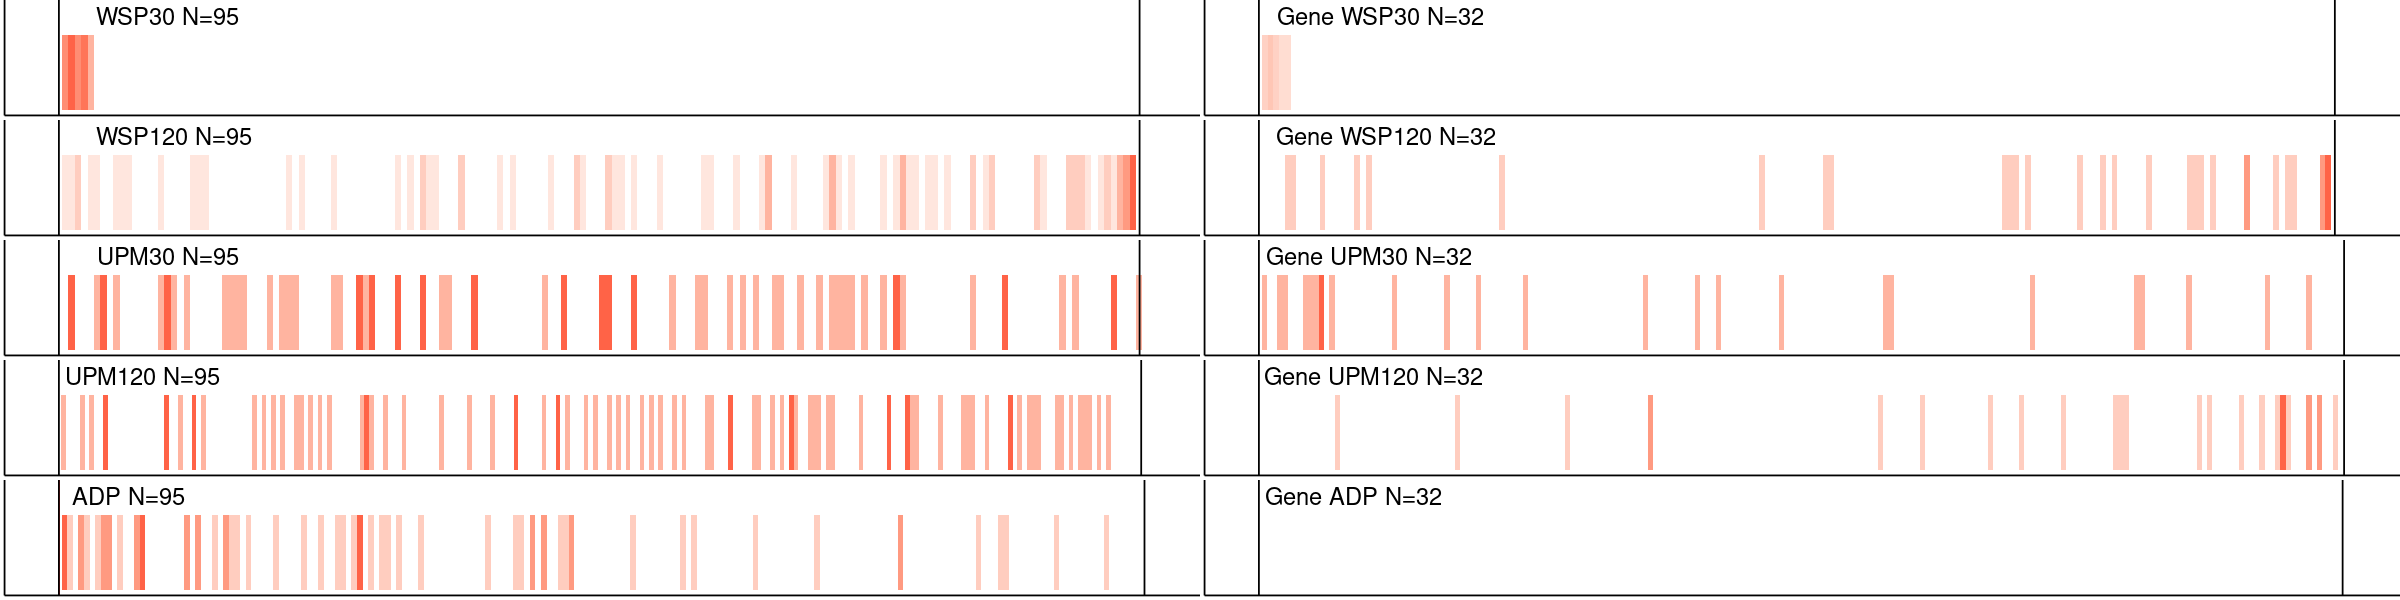

In [36]:
options(warn=-1)
graph_rankings("SRF.H12CORE.0.PSM.A", pro_30_srf_gene, pro_30_srf, file_save="./plots/SRF_rankings.pdf", color="tomato")

## 2. AHR

In [25]:
TF="AHR.H12CORE.0.P.B"

In [26]:
#nontss_res_W30[1:3,]

In [29]:
ranked_file = paste0(wspindir, "NonTSS_WSP30_vs_Veh_par_rat_Wd_GeneHK.bed")
resdir = paste0(outdir, "WSP/TFEA/out/NonTSS_WSP30vsVeh_par_rat_Wd_GeneHK_noback/")
wsp_30_ahr = get_LE_calls(resdir, ranked_file, "AHR.H12CORE.0.P.B")

ranked_file = paste0(wspindir, "GeneTSS_WSP30_vs_Veh_par_rat_Wd_GeneHK.bed")
resdir = paste0(outdir, "WSP/TFEA/out/Gene_WSP30vsVeh_par_rat_Wd_GeneHK_noback/")
wsp_30_ahr_gene = get_LE_calls(resdir, ranked_file, "AHR.H12CORE.0.P.B", FALSE)


ranked_file = paste0(upmindir, "NonTSS_UPM30_vs_Veh_par_rat_Wd_GeneHK.bed")
resdir = paste0(outdir, "UPM/TFEA/out/NonTSS_UPM30vsVeh_par_rat_Wd_GeneHK_noback/")
upm_30_ahr = get_LE_calls(resdir, ranked_file, "AHR.H12CORE.0.P.B")

ranked_file = paste0(upmindir, "GeneTSS_UPM30_vs_Veh_par_rat_Wd_GeneHK.bed")
resdir = paste0(outdir, "UPM/TFEA/out/Gene_UPM30vsVeh_par_rat_Wd_GeneHK_noback/")
upm_30_ahr_gene = get_LE_calls(resdir, ranked_file, "AHR.H12CORE.0.P.B", FALSE)


ranked_file = paste0(wspindir, "NonTSS_WSP120_vs_Veh_par_rat_Wd_GeneHK.bed")
resdir = paste0(outdir, "WSP/TFEA/out/NonTSS_WSP120vsVeh_par_rat_Wd_GeneHK_noback/")
wsp_120_ahr = get_LE_calls(resdir, ranked_file, "AHR.H12CORE.0.P.B")

ranked_file = paste0(wspindir, "GeneTSS_WSP120_vs_Veh_par_rat_Wd_GeneHK.bed")
resdir = paste0(outdir, "WSP/TFEA/out/Gene_WSP120vsVeh_par_rat_Wd_GeneHK_noback/")
wsp_120_ahr_gene = get_LE_calls(resdir, ranked_file, "AHR.H12CORE.0.P.B", FALSE)


ranked_file = paste0(upmindir, "NonTSS_UPM120_vs_Veh_par_rat_Wd_GeneHK.bed")
resdir = paste0(outdir, "UPM/TFEA/out/NonTSS_UPM120vsVeh_par_rat_Wd_GeneHK_noback/")
upm_120_ahr = get_LE_calls(resdir, ranked_file, "AHR.H12CORE.0.P.B")

ranked_file = paste0(upmindir, "GeneTSS_UPM120_vs_Veh_par_rat_Wd_GeneHK.bed")
resdir = paste0(outdir, "UPM/TFEA/out/Gene_UPM120vsVeh_par_rat_Wd_GeneHK_noback/")
upm_120_ahr_gene = get_LE_calls(resdir, ranked_file, "AHR.H12CORE.0.P.B", FALSE)

 [1]   2  25  30  36  39  40  63  64  69  73 104 107 111 138 198 252 289 304 345
[20] 347 348 355 360 363 588 592

 AHR LE: 596 	EScore: 0.005724196 	CorrEScore: 0.1265469 	Num in LE mu500: 26
No significant calls for this 1 1 [1] 44572 44589 44642 44762 44801 44825 44867 44878 44906 44909 44919 44954
[13] 44969 44999 45031 45050 45051 45074 45092 45095 45102 45202 45204 45256
[25] 45315 45350 45457 45459 45544 45582 45584 45679 45707 45804 45811 45842
[37] 45918 45943 45972 46042 46050 46126 46153 46213 46278 46370

 AHR LE: 44365 	EScore: -0.01140734 	CorrEScore: 0.09928162 	Num in LE mu500: 46
No significant calls for this 1 1 [1] 31957 32011 32013 32037 32090 32105 32113 32139 32149 32159 32173 32177
[13] 32190 32197 32244 32292 32325 32339 32455 32486 32502 32620 32655 32664
[25] 32682 32684 32721 32730 32744 32762 32811 32903 32926 32927 32983 33008
[37] 33018 33040 33051 33058 33072 33073 33077 33098 33101 33154 33185 33198
[49] 33306 33308 33355 33358 33373 33410 33422 33438 33


    0    LE 
46363    46 

    0    LE 
46363    46 

Ranked UPM30 46409UPM30 11 	UPM120 218 	WSP120 164
  0   1   2   3 
117  20   9   1 

    0    LE 
46385    24 

    0    LE 
46385    24 

Ranked UPM30 46409UPM30 215 	UPM120 227 	WSP120 97
 0  2  9 15 
 1  1  1  1 


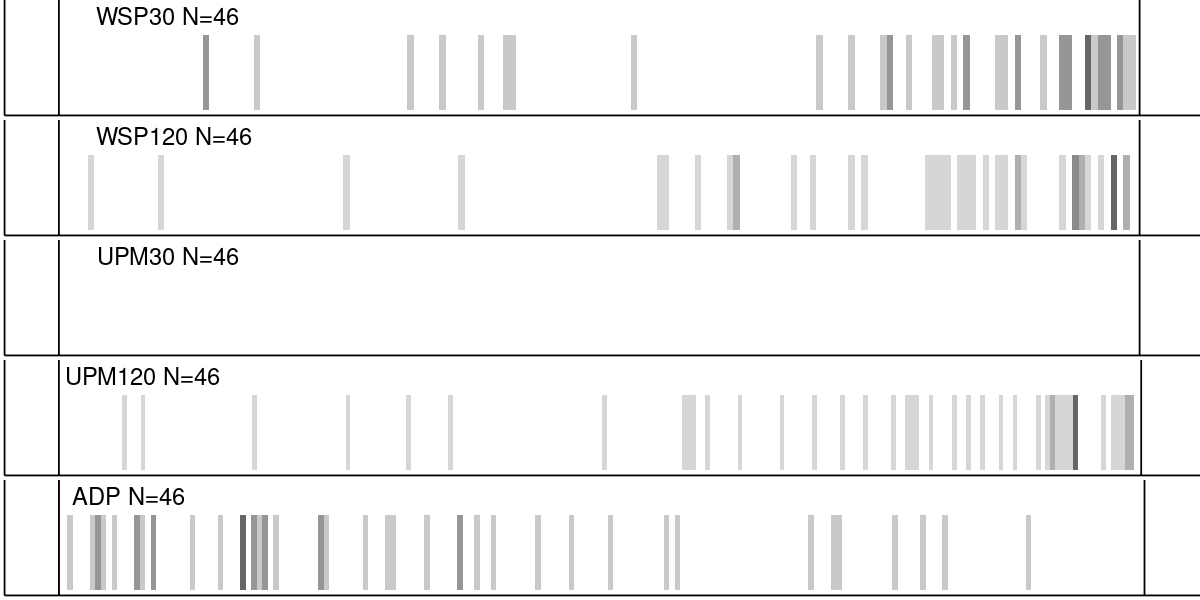


    0    LE 
46344    65 

    0    LE 
46344    65 

Ranked UPM30 46409UPM30 233 	UPM120 231 	WSP120 12
  0   1   2   3   4   6  10 
132  24   6   5   1   1   1 


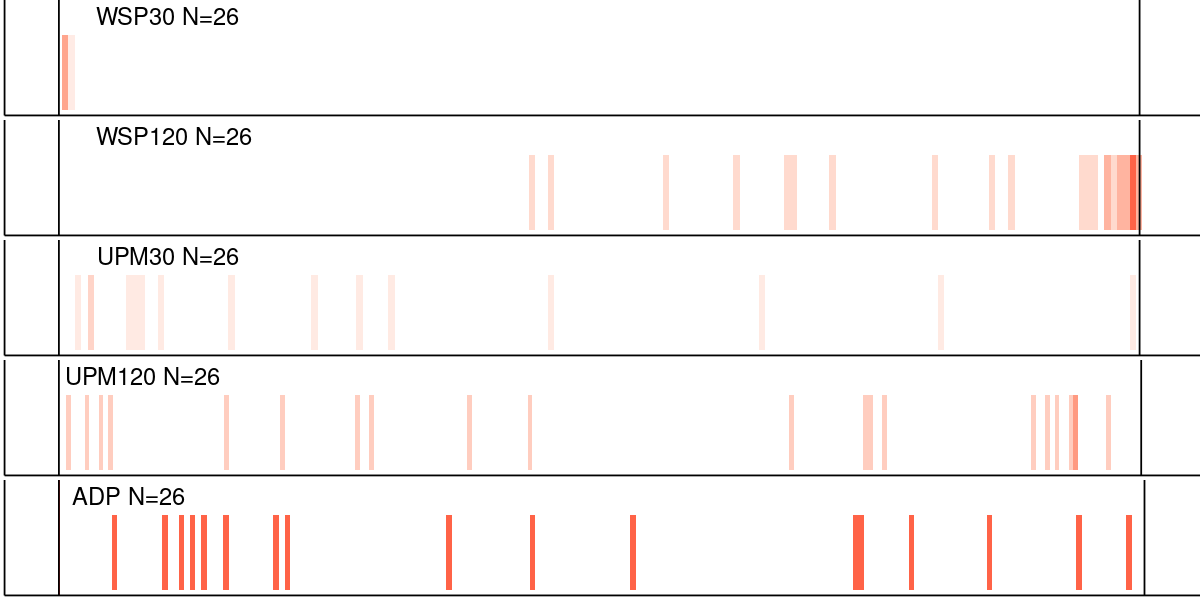

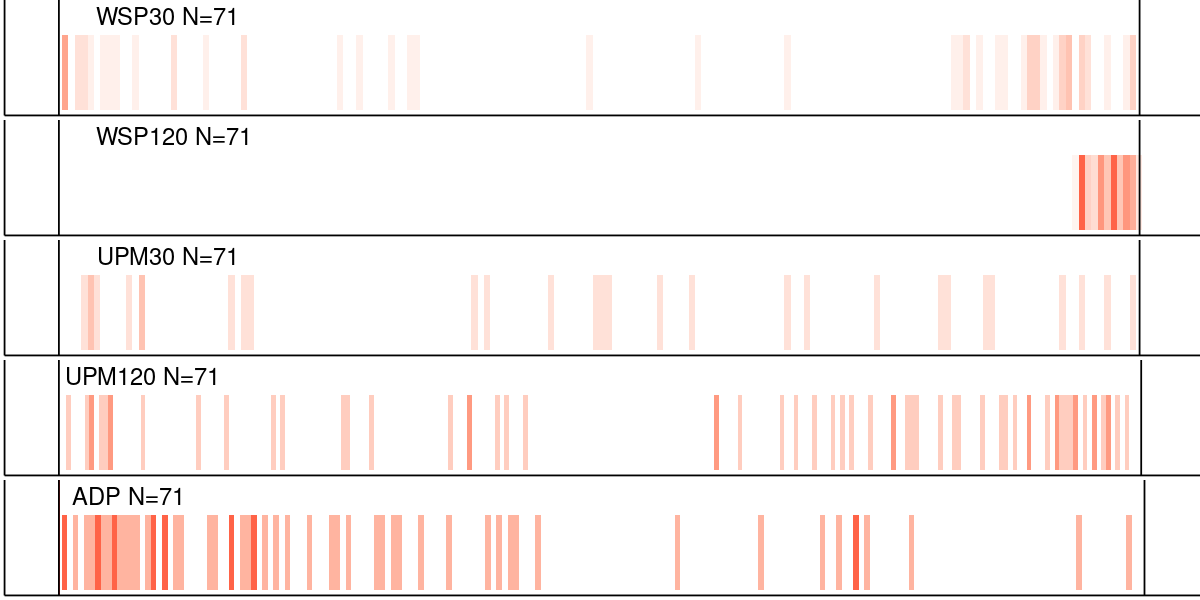

In [40]:
graph_rankings("AHR.H12CORE.0.P.B", upm_30_ahr, upm_30_ahr, gene=FALSE, "./plots/AHR_rankings_UPM30.pdf", color="grey40")
graph_rankings("AHR.H12CORE.0.P.B", wsp_30_ahr, wsp_30_ahr, gene=FALSE, "./plots/AHR_rankings_WSP30.pdf", color="tomato")
graph_rankings("AHR.H12CORE.0.P.B", wsp_30_ahr, wsp_120_ahr, gene=FALSE, "./plots/AHR_rankings_WSP120.pdf", color="tomato")

In [33]:
ranked_file = paste0(wspindir, "NonTSS_WSP30_vs_Veh_par_rat_Wd_GeneHK.bed")
resdir = paste0(outdir, "WSP/TFEA/out/NonTSS_WSP30vsVeh_par_rat_Wd_GeneHK_noback/")
wsp_30_ahrr = get_LE_calls(resdir, ranked_file, "AHRR.H12CORE.0.P.C")

ranked_file = paste0(wspindir, "GeneTSS_WSP30_vs_Veh_par_rat_Wd_GeneHK.bed")
resdir = paste0(outdir, "WSP/TFEA/out/Gene_WSP30vsVeh_par_rat_Wd_GeneHK_noback/")
wsp_30_ahrr_gene = get_LE_calls(resdir, ranked_file, "AHRR.H12CORE.0.P.C", FALSE)


ranked_file = paste0(upmindir, "NonTSS_UPM30_vs_Veh_par_rat_Wd_GeneHK.bed")
resdir = paste0(outdir, "UPM/TFEA/out/NonTSS_UPM30vsVeh_par_rat_Wd_GeneHK_noback/")
upm_30_ahrr = get_LE_calls(resdir, ranked_file, "AHRR.H12CORE.0.P.C")

ranked_file = paste0(upmindir, "GeneTSS_UPM30_vs_Veh_par_rat_Wd_GeneHK.bed")
resdir = paste0(outdir, "UPM/TFEA/out/Gene_UPM30vsVeh_par_rat_Wd_GeneHK_noback/")
upm_30_ahrr_gene = get_LE_calls(resdir, ranked_file, "AHRR.H12CORE.0.P.C", FALSE)


ranked_file = paste0(wspindir, "NonTSS_WSP120_vs_Veh_par_rat_Wd_GeneHK.bed")
resdir = paste0(outdir, "WSP/TFEA/out/NonTSS_WSP120vsVeh_par_rat_Wd_GeneHK_noback/")
wsp_120_ahrr = get_LE_calls(resdir, ranked_file, "AHRR.H12CORE.0.P.C")

ranked_file = paste0(wspindir, "GeneTSS_WSP120_vs_Veh_par_rat_Wd_GeneHK.bed")
resdir = paste0(outdir, "WSP/TFEA/out/Gene_WSP120vsVeh_par_rat_Wd_GeneHK_noback/")
wsp_120_ahrr_gene = get_LE_calls(resdir, ranked_file, "AHRR.H12CORE.0.P.C", FALSE)


ranked_file = paste0(upmindir, "NonTSS_UPM120_vs_Veh_par_rat_Wd_GeneHK.bed")
resdir = paste0(outdir, "UPM/TFEA/out/NonTSS_UPM120vsVeh_par_rat_Wd_GeneHK_noback/")
upm_120_ahrr = get_LE_calls(resdir, ranked_file, "AHRR.H12CORE.0.P.C")

ranked_file = paste0(upmindir, "GeneTSS_UPM120_vs_Veh_par_rat_Wd_GeneHK.bed")
resdir = paste0(outdir, "UPM/TFEA/out/Gene_UPM120vsVeh_par_rat_Wd_GeneHK_noback/")
upm_120_ahrr_gene = get_LE_calls(resdir, ranked_file, "AHRR.H12CORE.0.P.C", FALSE)

 [1]    2   98  104  168  180  234  258  328  345  375  377  383  389  418  582
[16]  585  592  622  630  632  736  796  812  893  995 1002 1037 1152 1229 1273
[31] 1308 1356 1358 1371 1386 1414 1529 1539 1632 1669 1676 1877 1899 1932 1970
[46] 2016 2065 2072 2184 2271 2345 2420 2427 2442 2455 2465 2545

 AHRR LE: 2556 	EScore: 0.1076459 	CorrEScore: 0.1811647 	Num in LE mu500: 57
No significant calls for this 1 1 [1]    1    2   59   62   67   76   88   94  144  163  179  194  196  261  399
[16]  425  456  469  472  482  500  547  571  583  639  659  729  837  881  894
[31]  943  978  988 1045 1054 1090 1115 1131 1138 1155 1190 1222 1226 1269 1355
[46] 1403 1519 1557 1578 1666 1689 1695 1771 1798 1811 1875 2116 2209 2248 2398
[61] 2406 2569 2583 2644 2684 2685 2748 2772 2908 2983 3067 3114 3161 3185 3214
[76] 3284 3306 3313

 AHRR LE: 3356 	EScore: 0.07030641 	CorrEScore: 0.1391281 	Num in LE mu500: 78
No significant calls for this 1 1 [1] 32062 32139 32147 32244 32344 32351 32380 324


    0    LE 
46331    78 

    0    LE 
46331    78 

Ranked UPM30 46409UPM30 18 	UPM120 211 	WSP120 168
  0   1   2   3   4   7 
124  29   5   1   1   1 

    0    LE 
46360    49 

    0    LE 
46360    49 

Ranked UPM30 46409UPM30 208 	UPM120 220 	WSP120 171
0 2 3 4 5 6 7 8 
1 1 4 3 2 1 1 1 


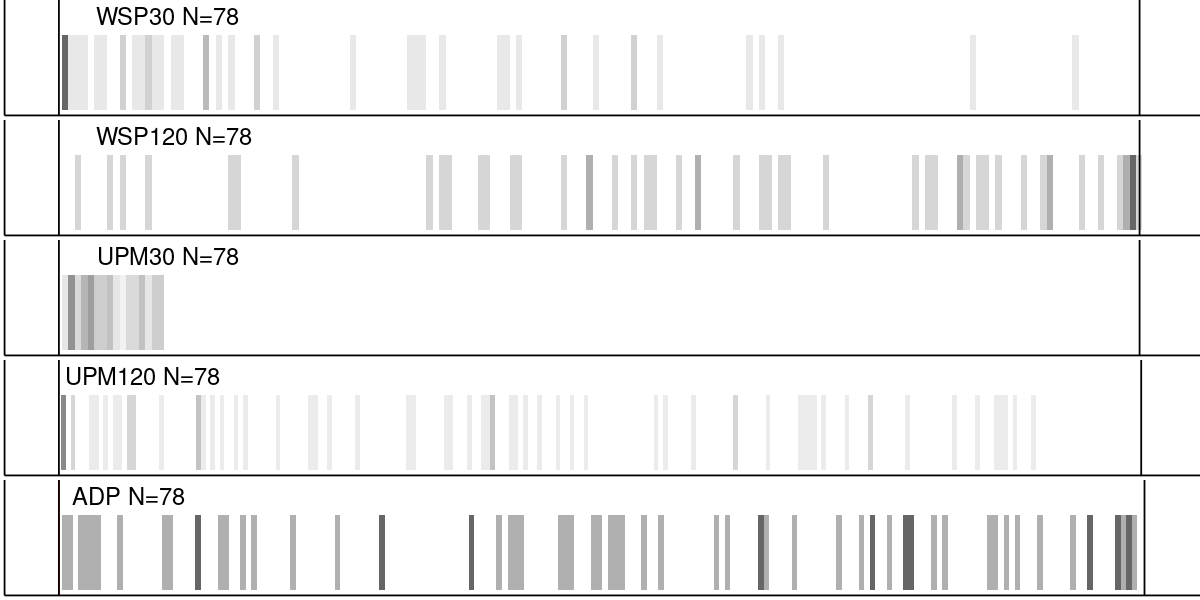

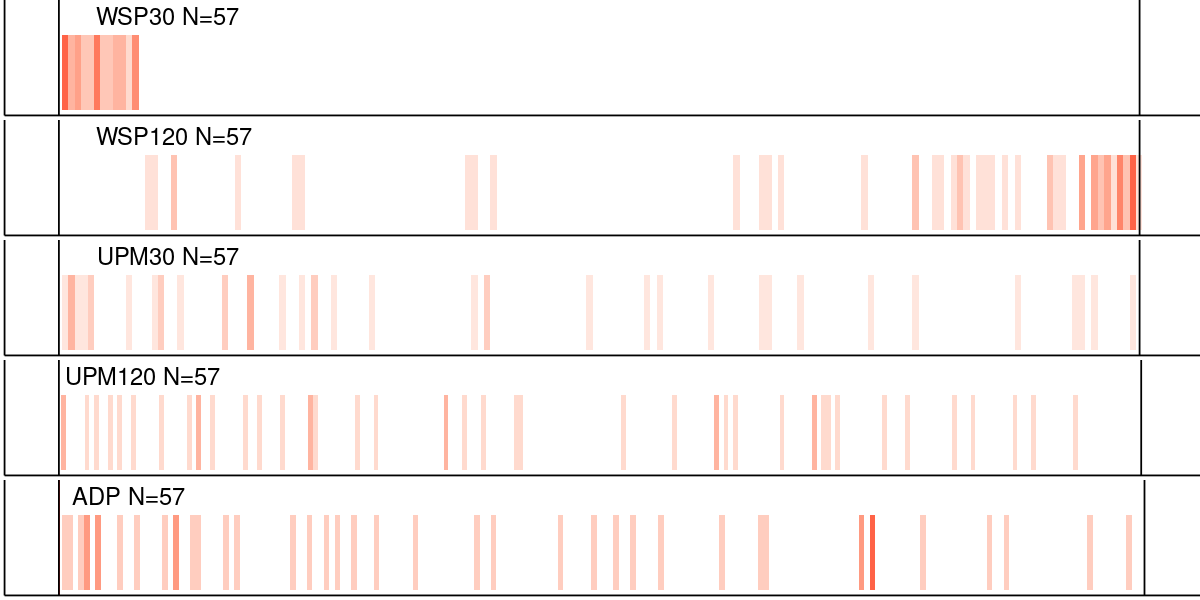

In [39]:
graph_rankings("AHRR.H12CORE.0.P.C", upm_30_ahrr, upm_30_ahrr, gene=FALSE, "./plots/AHRR_rankings_UPM30.pdf", color="grey40")
graph_rankings("AHRR.H12CORE.0.P.C", wsp_30_ahrr, wsp_30_ahrr, gene=FALSE, "./plots/AHRR_rankings_WSP30.pdf", color="tomato")

In [304]:
graph_rankings <- function(TF_use, gene_tss_list, nontss_list, gene=TRUE) {
    # Read in the ranked files
    ranked_wsp120 = read_ranked_file(paste0(wspindir, "NonTSS_WSP120_vs_Veh_par_rat_Wd_GeneHK.bed"))
    ranked_wsp30 = read_ranked_file(paste0(wspindir, "NonTSS_WSP30_vs_Veh_par_rat_Wd_GeneHK.bed"))
    ranked_wsp120_gene = read_ranked_file(paste0(wspindir, "GeneTSS_WSP120_vs_Veh_par_rat_Wd_GeneHK.bed"))
    ranked_wsp30_gene = read_ranked_file(paste0(wspindir, "GeneTSS_WSP30_vs_Veh_par_rat_Wd_GeneHK.bed"))
    
    
    ranked_upm120 = read_ranked_file(paste0(upmindir, "NonTSS_UPM120_vs_Veh_par_rat_Wd_GeneHK.bed"))
    ranked_upm30 = read_ranked_file(paste0(upmindir, "NonTSS_UPM30_vs_Veh_par_rat_Wd_GeneHK.bed"))
    ranked_upm120_gene = read_ranked_file(paste0(upmindir, "GeneTSS_UPM120_vs_Veh_par_rat_Wd_GeneHK.bed"))
    ranked_upm30_gene = read_ranked_file(paste0(upmindir, "GeneTSS_UPM30_vs_Veh_par_rat_Wd_GeneHK.bed"))
    
    adpindir = "/scratch/Users/hoto7260/Resp_Env/Comb_UPM_WSP_ADP/ADP/TFEA/input/"
    ranked_adp = read_ranked_file(paste0(adpindir, "NonTSS_ADP_vs_Veh_par_rat_Wd_HK.bed"))
    ranked_adp_gene = read_ranked_file(paste0(adpindir, "GeneTSS_ADP_vs_Veh_par_rat_Wd_HK.bed"))
    # Read in the distance files
    wspresdir = paste0(outdir, "WSP/TFEA/out")
    dist_wsp120 = fread(paste0(wspresdir, "/NonTSS_WSP120vsVeh_par_rat_Wd_GeneHK_noback/temp_files/withAUC", TF_use, "__dis_andmore.csv"), sep=",")
    dist_wsp30 = fread(paste0(wspresdir, "/NonTSS_WSP30vsVeh_par_rat_Wd_GeneHK_noback/temp_files/withAUC", TF_use, "__dis_andmore.csv"), sep=",")
    dist_wsp120_gene = fread(paste0(wspresdir, "/Gene_WSP120vsVeh_par_rat_Wd_GeneHK_noback/temp_files/withAUC", TF_use, "__dis_andmore.csv"), sep=",")
    dist_wsp30_gene = fread(paste0(wspresdir, "/Gene_WSP30vsVeh_par_rat_Wd_GeneHK_noback/temp_files/withAUC", TF_use, "__dis_andmore.csv"), sep=",")
    upmresdir = paste0(outdir, "UPM/TFEA/out")
    dist_upm120 = fread(paste0(upmresdir, "/NonTSS_UPM120vsVeh_par_rat_Wd_GeneHK_noback/temp_files/withAUC", TF_use, "__dis_andmore.csv"), sep=",")
    dist_upm30 = fread(paste0(upmresdir, "/NonTSS_UPM30vsVeh_par_rat_Wd_GeneHK_noback/temp_files/withAUC", TF_use, "__dis_andmore.csv"), sep=",")
    dist_upm120_gene = fread(paste0(upmresdir, "/Gene_UPM120vsVeh_par_rat_Wd_GeneHK_noback/temp_files/withAUC", TF_use, "__dis_andmore.csv"), sep=",")
    dist_upm30_gene = fread(paste0(upmresdir, "/Gene_UPM30vsVeh_par_rat_Wd_GeneHK_noback/temp_files/withAUC", TF_use, "__dis_andmore.csv"), sep=",")
    adpresdir = paste0(outdir, "ADP/TFEA/out")
    dist_adp = fread(paste0(adpresdir, "/NonTSS_ADP_par_rat_Wd_HK_noback/temp_files/withAUC", TF_use, "__dis_andmore.csv"), sep=",")
    dist_adp_gene = fread(paste0(adpresdir, "/Gene_ADP_par_rat_Wd_HK_noback/temp_files/withAUC", TF_use, "__dis_andmore.csv"), sep=",")
    
    # Get info for TF
    gen_TF_use = str_split(TF_use, "[.]")[[1]][1]

    # Get the colors according to if in the 
    # gene_tss_list
    # nontss_list
    # Get the color for the rankings
    ranked_wsp120$Color <- "0"
    ranked_wsp30$Color <- "0"
    ranked_wsp120_gene$Color <- "0"
    ranked_wsp30_gene$Color <- "0"
    ranked_upm120$Color <- "0"
    ranked_upm30$Color <- "0"
    ranked_upm120_gene$Color <- "0"
    ranked_upm30_gene$Color <- "0"
    ranked_adp$Color <- "0"
    ranked_adp_gene$Color <- "0"

    ranked_wsp120[ranked_wsp120$name %in% nontss_list,]$Color <- "LE"
    ranked_wsp30[ranked_wsp30$name %in% nontss_list,]$Color <- "LE"
    ranked_upm120[ranked_upm120$name %in% nontss_list,]$Color <- "LE"
    ranked_upm30[ranked_upm30$name %in% nontss_list,]$Color <- "LE"
    ranked_adp[ranked_adp$name %in% nontss_list,]$Color <- "LE"
    ranked_wsp120_gene[ranked_wsp120_gene$name %in% gene_tss_list,]$Color <- "LE"
    ranked_wsp30_gene[ranked_wsp30_gene$name %in% gene_tss_list,]$Color <- "LE"
    ranked_upm120_gene[ranked_upm120_gene$name %in% gene_tss_list,]$Color <- "LE"
    ranked_upm30_gene[ranked_upm30_gene$name %in% gene_tss_list,]$Color <- "LE"
    ranked_adp_gene[ranked_adp_gene$name %in% gene_tss_list,]$Color <- "LE"
    print(table(ranked_upm30$Color))
    # Get the heatmap data
    get_heatmap_data <- function(ranked_df, bin_size = 200) {
      df <- as.data.table(ranked_df[ranked_df$Color %in% c("LE"), ])
      df[, V1_bin := floor(V1 / bin_size) * bin_size]
    
      # Create full bin sequence across the range of V1
      bin_range <- seq(floor(min(df$V1) / bin_size) * bin_size,
                       ceiling(max(df$V1) / bin_size) * bin_size,
                       by = bin_size)
    
      # Count observations in each bin
      heatmap_data <- df[, .N, by = V1_bin]
    
      # Merge with full bin range to ensure all bins are represented
      all_bins <- data.table(V1_bin = bin_range)
      heatmap_data <- merge(all_bins, heatmap_data, by = "V1_bin", all.x = TRUE)
      heatmap_data[is.na(N), N := 0]
    
      return(heatmap_data)
    }
    #print(table(ranked_upm30$Color))
    #cat("\nRanked UPM30", nrow(ranked_upm30))
    hmp_wsp30_data = get_heatmap_data(ranked_wsp30)
    hmp_wsp120_data = get_heatmap_data(ranked_wsp120)
    hmp_upm30_data = get_heatmap_data(ranked_upm30)
    hmp_upm120_data = get_heatmap_data(ranked_upm120)
    hmp_adp_data = get_heatmap_data(ranked_adp)
    #cat("UPM30", nrow(hmp_upm30_data), "\tUPM120", nrow(hmp_upm120_data), "\tWSP120", nrow(hmp_wsp120_data))
    #print(table(hmp_wsp30_data$N))
    if (gene == TRUE) {
        hmp_wsp30_gene_data = get_heatmap_data(ranked_wsp30_gene, 100)
        hmp_wsp120_gene_data = get_heatmap_data(ranked_wsp120_gene, 100)
        hmp_upm30_gene_data = get_heatmap_data(ranked_upm30_gene, 100)
        hmp_upm120_gene_data = get_heatmap_data(ranked_upm120_gene, 100)
        hmp_adp_gene_data = get_heatmap_data(ranked_adp_gene, 100)
        }
    
    # Plot with geom_tile
    no_margin_theme <- theme(
      plot.margin = margin(0, 0, 0, 0),  # Remove outer margins
      axis.text = element_blank(),       # Remove axis text
      axis.ticks = element_blank(),      # Remove axis ticks
      panel.spacing = unit(0, "lines"),  # Remove spacing between facets
      panel.grid = element_blank(),      # Remove grid lines
        axis.title = element_blank(), 
     legend.position = "none",           # Remove legend if not needed
        axis.line = element_line(color = "black")
    )
    x_range <- range(ranked_wsp30$V1) 
    p1 = ggplot(hmp_wsp30_data, aes(x = V1_bin, y = 1, fill = N)) +
      geom_tile() + scale_fill_gradient(low = "white", high = "blue") +
      labs(fill = "Count") + theme_minimal() + ylim(0.5, 1.9) + no_margin_theme + geom_vline(xintercept=0, color="black") + 
    geom_vline(xintercept=nrow(ranked_wsp30), color="black") +
    scale_x_continuous(limits = range(floor(x_range[1]/200)*200, ceiling(x_range[2]/200)*200)) +
    annotate("text", label=paste0("WSP30 N=", length(nontss_list)), x=3400, y = 1.75, size=5)
    x_range <- range(ranked_wsp120$V1) 
    p2 = ggplot(hmp_wsp120_data, aes(x = V1_bin, y = 1, fill = N)) +
      geom_tile() + scale_fill_gradient(low = "white", high = "blue") + geom_vline(xintercept=0, color="black") + 
    geom_vline(xintercept=nrow(ranked_wsp120), color="black") +
      labs(fill = "Count") + theme_minimal() +  no_margin_theme + ylim(0.5, 1.9) +
    scale_x_continuous(limits = range(floor(x_range[1]/200)*200, ceiling(x_range[2]/200)*200)) +
    annotate("text", label=paste0("WSP120 N=", length(nontss_list)), x=3600, y = 1.75, size=5)
    x_range <- range(ranked_upm30$V1) 
    p3 = ggplot(hmp_upm30_data, aes(x = V1_bin, y = 1, fill = N)) +
      geom_tile() + scale_fill_gradient(low = "white", high = "blue") +
      labs(fill = "Count") + theme_minimal() + ylim(0.5, 1.9) + geom_vline(xintercept=0, color="black") + 
    geom_vline(xintercept=nrow(ranked_upm30), color="black") + no_margin_theme +
    scale_x_continuous(limits = range(floor(x_range[1]/200)*200, ceiling(x_range[2]/200)*200)) +
    annotate("text", label=paste0("UPM30 N=", length(nontss_list)), x=3400, y = 1.75, size=5)
    x_range <- range(ranked_upm120$V1) 
    p4 = ggplot(hmp_upm120_data, aes(x = V1_bin, y = 1, fill = N)) +
      geom_tile() + scale_fill_gradient(low = "white", high = "blue") + geom_vline(xintercept=0, color="black") + 
    geom_vline(xintercept=nrow(ranked_upm120), color="black") +
      labs(fill = "Count") + theme_minimal() +  no_margin_theme + ylim(0.5, 1.9) +
    scale_x_continuous(limits = range(floor(x_range[1]/200)*200, ceiling(x_range[2]/200)*200)) +
    annotate("text", label=paste0("UPM120 N=", length(nontss_list)), x=3600, y = 1.75, size=5)
    x_range <- range(ranked_adp$V1) 
    p5 = ggplot(hmp_adp_data, aes(x = V1_bin, y = 1, fill = N)) +
      geom_tile() + scale_fill_gradient(low = "white", high = "blue") +
      labs(fill = "Count") + theme_minimal() + 
     no_margin_theme + ylim(0.5, 1.9) + geom_vline(xintercept=0, color="red") + 
    geom_vline(xintercept=0, color="black") + geom_vline(xintercept=nrow(ranked_adp), color="black") +
    scale_x_continuous(limits = range(floor(x_range[1]/200)*200, ceiling(x_range[2]/200)*200)) +
    annotate("text", label=paste0("ADP N=", length(nontss_list)), x=2500, y = 1.75, size=5)

    if (gene == TRUE) {
     x_range <- range(ranked_wsp30_gene$V1) 
    p6 = ggplot(hmp_wsp30_gene_data, aes(x = V1_bin, y = 1, fill = N)) +
      geom_tile() + scale_fill_gradient(low = "white", high = "blue") +
      labs(fill = "Count") + theme_minimal() + ylim(0.5, 1.9) + geom_vline(xintercept=0, color="black") + 
    geom_vline(xintercept=nrow(ranked_wsp30_gene), color="black") +
    scale_x_continuous(limits = range(floor(x_range[1]/200)*200, ceiling(x_range[2]/200)*200)) +
    annotate("text", label=paste0("Gene WSP30 N=", length(gene_tss_list)), x=2100, y = 1.75, size=5) + no_margin_theme
    x_range <- range(ranked_wsp120_gene$V1) 
    p7 = ggplot(hmp_wsp120_gene_data, aes(x = V1_bin, y = 1, fill = N)) +
      geom_tile() + scale_fill_gradient(low = "white", high = "blue") +
      labs(fill = "Count") + theme_minimal() +  ylim(0.5, 1.9) + geom_vline(xintercept=0, color="black") + 
    geom_vline(xintercept=nrow(ranked_wsp120_gene), color="black") +
    scale_x_continuous(limits = range(floor(x_range[1]/200)*200, ceiling(x_range[2]/200)*200)) +
    annotate("text", label=paste0("Gene WSP120 N=", length(gene_tss_list)), x=2200, y = 1.75, size=5) + no_margin_theme
    x_range <- range(ranked_upm30_gene$V1) 
    p8 = ggplot(hmp_upm30_gene_data, aes(x = V1_bin, y = 1, fill = N)) +
      geom_tile() + scale_fill_gradient(low = "white", high = "blue") +
      labs(fill = "Count") + theme_minimal() + ylim(0.5, 1.9) + geom_vline(xintercept=0, color="black") + 
    geom_vline(xintercept=nrow(ranked_upm30_gene), color="black") +
    scale_x_continuous(limits = range(floor(x_range[1]/200)*200, ceiling(x_range[2]/200)*200)) +
    annotate("text", label=paste0("Gene UPM30 N=", length(gene_tss_list)), x=2100, y = 1.75, size=5) + no_margin_theme
    x_range <- range(ranked_upm120_gene$V1) 
    p9 = ggplot(hmp_upm120_gene_data, aes(x = V1_bin, y = 1, fill = N)) +
      geom_tile() + scale_fill_gradient(low = "white", high = "blue") +
      labs(fill = "Count") + theme_minimal() +  ylim(0.5, 1.9) + geom_vline(xintercept=0, color="black") + 
    geom_vline(xintercept=nrow(ranked_upm120_gene), color="black") +
    scale_x_continuous(limits = range(floor(x_range[1]/200)*200, ceiling(x_range[2]/200)*200)) +
    annotate("text", label=paste0("Gene UPM120 N=", length(gene_tss_list)), x=2200, y = 1.75, size=5) + no_margin_theme
    x_range <- range(ranked_adp_gene$V1) 
    p10 = ggplot(hmp_adp_gene_data, aes(x = V1_bin, y = 1, fill = N)) +
      geom_tile() + scale_fill_gradient(low = "white", high = "blue") +
      labs(fill = "Count") + theme_minimal() + 
     no_margin_theme + ylim(0.5, 1.9) + geom_vline(xintercept=0, color="black") + 
    geom_vline(xintercept=nrow(ranked_adp_gene), color="black") +
    scale_x_continuous(limits = range(floor(x_range[1]/200)*200, ceiling(x_range[2]/200)*200)) +
    annotate("text", label=paste0("Gene ADP N=", length(gene_tss_list)), x=1500, y = 1.75, size=5)
        options(repr.plot.width = 20, repr.plot.height=5)
    print(plot_grid(p1, p6,    p2, p7,   p3, p8,   p4, p9,   p5, p10, nrow=5, 
                    # align = "hv", 
                    axis = "tblr",  # Ensure alignment
      greedy=TRUE))
    } else {

    options(repr.plot.width = 10, repr.plot.height=5)
    print(plot_grid(p1, p2,  p3, p4, p5,  nrow=5, 
                    # align = "hv", 
                    axis = "tblr",  # Ensure alignment
      greedy=TRUE))
    
    # NOW ATAC30 in PRO

    } }


### Compare Calls

[1] 18

[1] 60

[1] 39

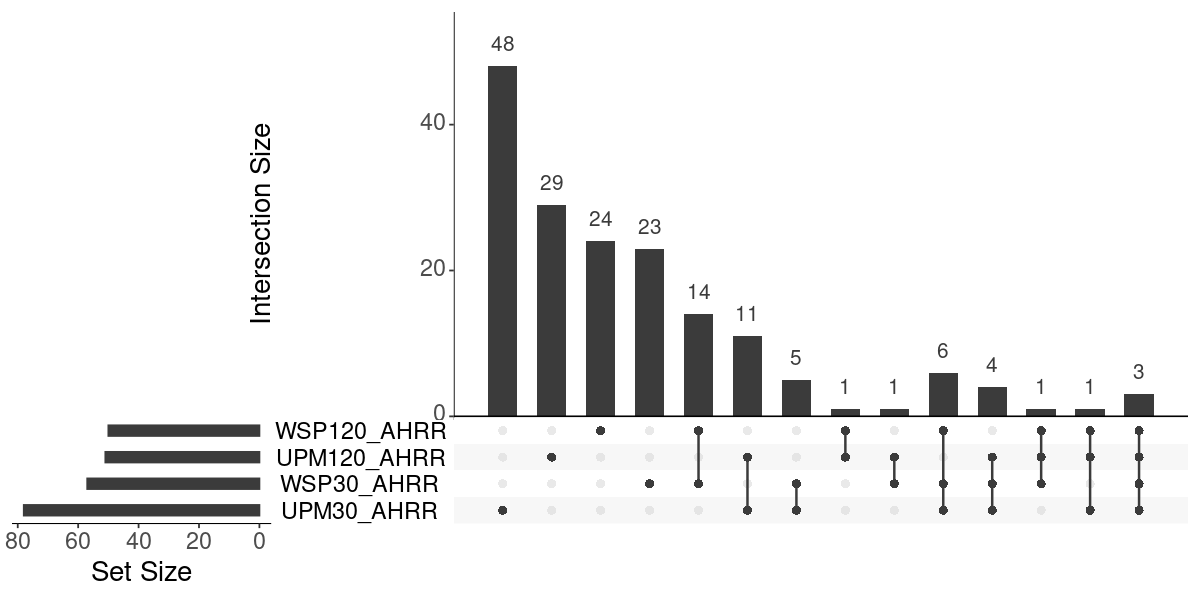

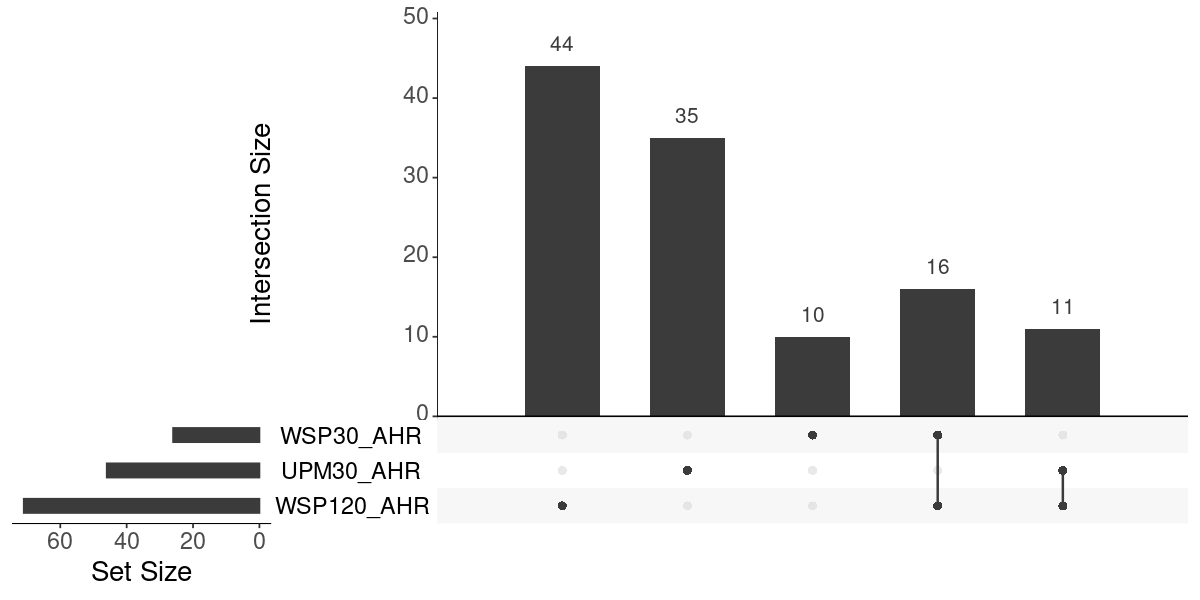

In [317]:
length(intersect(upm_30_ahrr, wsp_30_ahrr))
length(setdiff(upm_30_ahrr, wsp_30_ahrr))
length(setdiff(wsp_30_ahrr, upm_30_ahrr))

upset(fromList(list("WSP30_AHRR"=wsp_30_ahrr, "UPM30_AHRR"=upm_30_ahrr, 
                   "WSP120_AHRR"=wsp_120_ahrr, "UPM120_AHRR"=upm_120_ahrr)), text.scale=2)

upset(fromList(list("WSP30_AHR"=wsp_30_ahr, "UPM30_AHR"=upm_30_ahr, 
                   "WSP120_AHR"=wsp_120_ahr, "UPM120_AHR"=upm_120_ahr)), text.scale=2)